Label distribution:
label
1    42891
0    39595
Name: count, dtype: int64


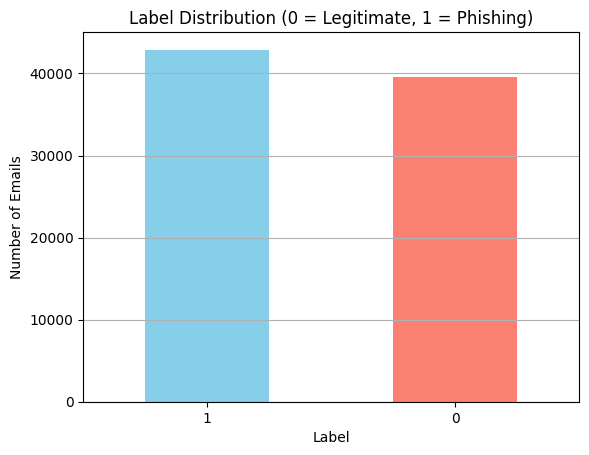

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("final_dataset_phishing_email.csv")

# Check label distribution
label_counts = df['label'].value_counts()
print("Label distribution:")
print(label_counts)

# Visualize the label distribution
label_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Label Distribution (0 = Legitimate, 1 = Phishing)")
plt.xlabel("Label")
plt.ylabel("Number of Emails")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

In [12]:
df.head()

,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [13]:
from sklearn.model_selection import train_test_split

# Feature (email text) and label
X = df['text_combined']   # Raw email content
y = df['label']           # 0 = legitimate, 1 = phishing

# Split the dataset into training (90%) and test (10%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 74237
Test samples: 8249


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the vectorizer
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000  # limit to top 5000 words
)

# Fit on training data only
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform the test data using the same vectorizer
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF feature matrix (train):", X_train_tfidf.shape)
print("TF-IDF feature matrix (test):", X_test_tfidf.shape)

TF-IDF feature matrix (train): (74237, 5000)
TF-IDF feature matrix (test): (8249, 5000)


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import numpy as np

# 使用调过参的 Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)

# 5折交叉验证评估
scores = cross_val_score(rf, X_train_tfidf, y_train, cv=5, scoring='f1')
print("F1 scores from each fold:", scores)
print("Average F1 score:", np.mean(scores))

# 在训练集上训练，并在测试集上预测
rf.fit(X_train_tfidf, y_train)
y_pred = rf.predict(X_test_tfidf)

# 打印结果
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


F1 scores from each fold: [0.9602865  0.96043464 0.96034847 0.95710456 0.96062891]
Average F1 score: 0.9597606176469211
Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.93      0.95      3960
           1       0.94      0.98      0.96      4289

    accuracy                           0.96      8249
   macro avg       0.96      0.95      0.96      8249
weighted avg       0.96      0.96      0.96      8249

Confusion Matrix:

[[3695  265]
 [ 100 4189]]
